In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from utils_functions import *

In [51]:
import networkx as nx
import pandas as pd
from networkx import community

def build_graph_from_data(edges_path):
    """
    Loads the datasets and builds a Graph where nodes are authors 
    and edges represent interactions (comments on posts).
    """
    # Load datasets
    df_edges = pd.read_csv(edges_path)
    
    # Standardizing columns: Linking commenters (Source) to post authors (Target)
    # Based on your previous logic, we ensure the graph captures user-to-user interaction
    G_directed = nx.DiGraph()
    for _, row in df_edges.iterrows():
            G_directed.add_edge(row['Source'], row['Target'], weight=row['Weight'])

    G = nx.from_pandas_edgelist(
        df_edges, 
        source='Source', 
        target='Target', 
        create_using=nx.Graph(),
        edge_attr='Weight'
    )
    
    print(f"Graph initialized: {G.number_of_nodes()} users, {G.number_of_edges()} interactions.")
    return G , G_directed


def detect_communities(G):
    """
    Implements the Louvain algorithm to identify modular communities.
    Returns a dictionary mapping {User: Community_ID}.
    """
    # Louvain algorithm for modularity optimization
    communities_list = nx.community.louvain_communities(G, seed=42)
    
    # Convert list of sets to a flat dictionary mapping
    community_mapping = {node: i for i, comm in enumerate(communities_list) for node in comm}
    
    print(f"Community Detection: Found {len(communities_list)} distinct groups.")
    return community_mapping

def calculate_centrality(G):
    """
    Calculates Betweenness (bridges) and PageRank (influencers).
    """
    print("Calculating Betweenness Centrality (using sampling for speed)...")
    # k=500 provides a good approximation for large graphs
    betweenness = nx.betweenness_centrality(G, k=500, seed=42)
    
    print("Calculating PageRank Centrality...")
    pagerank = nx.pagerank(G)
    
    return betweenness, pagerank

def identify_core_periphery(G):
    """
    Applies k-core decomposition to separate the highly engaged 
    'backbone' from casual participants.
    """
    # core_number returns the highest k-core each node belongs to
    core_numbers = nx.core_number(G)
    return core_numbers


    metrics = []
    for node in G_directed.nodes():
        metrics.append({
            'User': node,
            'Betweenness_Centrality': betweenness.get(node, 0),
            'PageRank': pagerank.get(node, 0),
            'Community_ID': louvain_partition.get(node, -1),
            'Core_Number': core_numbers.get(node, 0),
        })

def generate_degree_metrics(G):
    metrics = []
    for node in G.nodes():
        metrics.append({
            'Degree': G.degree(node),
        })
    return pd.DataFrame(metrics)

def generate_directed_report(G_directed):

    deg_dict = dict(G_directed.degree())
    in_deg_dict = dict(G_directed.in_degree())
    out_deg_dict = dict(G_directed.out_degree())
    

    communities = detect_communities(G_directed)
    betweenness, pagerank = calculate_centrality(G_directed)
    core_scores = identify_core_periphery(G_directed)

    nodes = list(G_directed.nodes())

    
    return pd.DataFrame({
        'User': nodes,
        'Community_ID': [communities.get(node) for node in nodes],
        'Betweenness_Score': [betweenness.get(node, 0) for node in nodes],
        'PageRank_Score': [pagerank.get(node, 0) for node in nodes],
        'Coreness_Level': [core_scores.get(node, 0) for node in nodes],
        'Degree': [deg_dict.get(node, 0) for node in nodes],
        'In_degree': [in_deg_dict.get(node, 0) for node in nodes],
        'Out_degree': [out_deg_dict.get(node, 0) for node in nodes]
    })

def generate_report(G):
    
    deg_dict = dict(G.degree())
    communities = detect_communities(G)
    betweenness, pagerank = calculate_centrality(G)
    core_scores = identify_core_periphery(G)
    nodes = list(G.nodes())

    
    return pd.DataFrame({
        'User': nodes,
        'Community_ID': [communities.get(node) for node in nodes],
        'Betweenness_Score': [betweenness.get(node, 0) for node in nodes],
        'PageRank_Score': [pagerank.get(node, 0) for node in nodes],
        'Coreness_Level': [core_scores.get(node, 0) for node in nodes],
        'Degree': [deg_dict.get(node, 0) for node in nodes],
    })
    

def generate_analysis_report(G , G_directed):
    """
    Executes all analyses and merges them into a single analytical DataFrame.
    """
    directed_report = generate_directed_report(G_directed)
    undirected_report = generate_report(G)

 
    
    # Label Core vs Periphery (Top 10% of coreness is considered the backbone)
    core_threshold = undirected_report['Coreness_Level'].quantile(0.9)
    undirected_report['Network_Role'] = undirected_report['Coreness_Level'].apply(
        lambda x: 'Core (Backbone)' if x >= core_threshold else 'Periphery'
    )

    return  undirected_report  , directed_report

def detect_anomalies(node_report, betweenness_threshold=0.8, pagerank_threshold=0.2):
    """
    Identifies suspicious users based on topological heuristics.
    - Potential Raid Leader: High Betweenness + High Coreness + Low PageRank.
    - Bridge/Troll: High Betweenness + Linking different communities.
    """
    
    # Normalize metrics between 0 and 1 for easier heuristic comparison
    metrics = ['Betweenness_Score', 'PageRank_Score', 'Coreness_Level']
    node_report_norm = node_report.copy()
    for m in metrics:
        node_report_norm[m] = (node_report[m] - node_report[m].min()) / (node_report[m].max() - node_report[m].min())

    alerts = []

    for index, row in node_report_norm.iterrows():
        # HEURISTIC 1: The "Raid Leader" / "Bridge Troll"
        # High Betweenness (top 10%) but relatively low PageRank (not a community pillar)
        if row['Betweenness_Score'] > node_report_norm['Betweenness_Score'].quantile(betweenness_threshold):
            if row['PageRank_Score'] < node_report_norm['PageRank_Score'].quantile(pagerank_threshold):
                alerts.append({
                    'User': row['User'],
                    'Type': 'Potential Bridge/Troll',
                    'Reason': 'High influence as a bridge but low community authority (PageRank).',
                    'Severity': 'High'
                })

        # HEURISTIC 2: Coordinated Backbone Member
        # High Coreness but very low PageRank (could be a bot or "sleeper" account)
        if row['Coreness_Level'] == 1.0 and row['PageRank_Score'] < 0.05:
            alerts.append({
                'User': row['User'],
                'Type': 'Suspicious Core Member',
                'Reason': 'Deeply embedded in the network backbone but has zero organic influence.',
                'Severity': 'Medium'
            })

    return pd.DataFrame(alerts)

def alert_community_manager(alerts_df):
    """
    Formats the alerts for a human Community Manager or DSA review.
    """
    if alerts_df.empty:
        print("✅ No suspicious patterns detected in this snapshot.")
    else:
        print(f"🚨 ALERT: {len(alerts_df)} suspicious users flagged for DSA review.")
        print("-" * 30)
        print(alerts_df.sort_values(by='Severity'))


def test_network_robustness(G, core_nodes):
    """
    Simulates the removal of core nodes and measures the impact on 
    the Largest Connected Component (LCC).
    """
    # Initial State
    initial_lcc_size = len(max(nx.connected_components(G), key=len))
    
    # Simulation: Remove identified core nodes
    G_fragmented = G.copy()
    G_fragmented.remove_nodes_from(core_nodes)
    
    # Final State
    final_lcc_size = len(max(nx.connected_components(G_fragmented), key=len)) if G_fragmented.nodes() else 0
    
    drop_percentage = ((initial_lcc_size - final_lcc_size) / initial_lcc_size) * 100
    
    print("--- Robustness Testing (Structural Pillars) ---")
    print(f"Initial LCC Size: {initial_lcc_size}")
    print(f"LCC Size after Core Removal: {final_lcc_size}")
    print(f"Network Fragmentation: {drop_percentage:.2f}% drop in connectivity.")
    
    return drop_percentage

def evaluate_filtering_impact(G, anomaly_nodes, community_mapping):
    """
    Compares global graph metrics (Modularity) before and after 
    filtering identified anomalies.
    """
    # Helper to convert mapping {node: cid} to list of sets [{n1, n2}, {n3}]
    def get_partition_list(nodes_to_keep, mapping):
        communities = {}
        for node in nodes_to_keep:
            cid = mapping[node]
            if cid not in communities: communities[cid] = set()
            communities[cid].add(node)
        return list(communities.values())

    # Initial Modularity
    initial_nodes = list(G.nodes())
    partition_initial = get_partition_list(initial_nodes, community_mapping)
    mod_initial = nx.community.modularity(G, partition_initial)
    
    # Filter Anomalies
    G_filtered = G.copy()
    G_filtered.remove_nodes_from(anomaly_nodes)
    
    # Final Modularity
    filtered_nodes = list(G_filtered.nodes())
    partition_filtered = get_partition_list(filtered_nodes, community_mapping)
    mod_filtered = nx.community.modularity(G_filtered, partition_filtered)
    
    print("\n--- Metric Evaluation (Noise Filtering) ---")
    print(f"Original Modularity: {mod_initial:.4f}")
    print(f"Filtered Modularity: {mod_filtered:.4f}")
    print(f"Improvement: {((mod_filtered - mod_initial) / mod_initial) * 100:.2f}%")
    
    return mod_initial, mod_filtered



def compute_weekly_metrics(G,df_sub):
    weeks = sorted(df_sub['ISOYearWeek'].unique())
    weekly_metrics = []
    
    for week in weeks:
        df_week = df_sub[df_sub['ISOYearWeek'] == week]
        
        # Build Directed and Undirected Graph
        if len(df_week) < 2:
            continue
            
        G.remove_edges_from(nx.selfloop_edges(G))
        G_undirected = G.to_undirected()
        
        # 1. Density
        density = nx.density(G)
        
        # 2. Modularity
        try:
            partition = community_louvain.best_partition(G_undirected, weight='weight')
            modularity = community_louvain.modularity(partition, G_undirected)
        except:
            modularity = 0.0
            
        # 3. Top Leader (by PageRank)
        try:
            pagerank = nx.pagerank(G_directed, weight='weight')
            if len(pagerank) > 0:
                top_leader = max(pagerank, key=pagerank.get)
                top_score = pagerank[top_leader]
            else:
                top_leader = None
                top_score = 0.0
        except:
            top_leader = None
            top_score = 0.0
            
        weekly_metrics.append({
            'ISOYearWeek': week,
            'Num_Nodes': len(G_directed.nodes()),
            'Num_Edges': len(G_directed.edges()),
            'Density': density,
            'Modularity': modularity,
            'Top_Leader': top_leader,
            'Top_Leader_Score': top_score
        })
        
    return pd.DataFrame(weekly_metrics)

In [37]:
def compute_weekly_metrics(df_sub):
    weeks = sorted(df_sub['ISOYearWeek'].unique())
    weekly_metrics = []
    
    for week in weeks:
        df_week = df_sub[df_sub['ISOYearWeek'] == week]
        
        # Build Directed and Undirected Graph
        if len(df_week) < 2:
            continue
            
        G_directed = nx.DiGraph()
        for _, row in df_week.iterrows():
            G_directed.add_edge(row['Source'], row['Target'], weight=row['Weight'])
        G_directed.remove_edges_from(nx.selfloop_edges(G_directed))
        G_undirected = G_directed.to_undirected()
        
        # 1. Density
        density = nx.density(G_directed)
        
        # 2. Modularity
        try:
            partition = community_louvain.best_partition(G_undirected, weight='weight')
            modularity = community_louvain.modularity(partition, G_undirected)
        except:
            modularity = 0.0
            
        # 3. Top Leader (by PageRank)
        try:
            pagerank = nx.pagerank(G_directed, weight='weight')
            if len(pagerank) > 0:
                top_leader = max(pagerank, key=pagerank.get)
                top_score = pagerank[top_leader]
            else:
                top_leader = None
                top_score = 0.0
        except:
            top_leader = None
            top_score = 0.0
            
        weekly_metrics.append({
            'ISOYearWeek': week,
            'Num_Nodes': len(G_directed.nodes()),
            'Num_Edges': len(G_directed.edges()),
            'Density': density,
            'Modularity': modularity,
            'Top_Leader': top_leader,
            'Top_Leader_Score': top_score
        })
        
    return pd.DataFrame(weekly_metrics)

In [38]:
def compute_all_weekly_metrics(edges_file):
    
    edges_df = pd.read_csv(edges_file)
    subreddits = edges_df['Subreddit'].unique()

    all_dynamic_metrics = []

    for subreddit in subreddits:
        print(f"Processing Subreddit: {subreddit}...")
        df_sub = edges_df[edges_df['Subreddit'] == subreddit]
        
        # Compute metrics for each available week
        weekly_metrics_df = compute_weekly_metrics(df_sub)
        if len(weekly_metrics_df) == 0:
            continue
            
        weekly_metrics_df['Subreddit'] = subreddit
        
        # Compute Week-over-Week Changes (Evolution Metrics)
        weekly_metrics_df['Delta_Density'] = weekly_metrics_df['Density'].diff().fillna(0)
        weekly_metrics_df['Delta_Modularity'] = weekly_metrics_df['Modularity'].diff().fillna(0)
        
        # Leader change flag
        weekly_metrics_df['Leader_Changed'] = (weekly_metrics_df['Top_Leader'] != weekly_metrics_df['Top_Leader'].shift(1)).astype(int)
        # The first week should technically not be a 'change' since there's no prior week, or we can leave it as 1 to indicate initiation.
        
        all_dynamic_metrics.append(weekly_metrics_df)
        
    final_dynamic_df = pd.concat(all_dynamic_metrics, ignore_index=True)

    # Rearrange columns
    cols = ['Subreddit', 'ISOYearWeek', 'Num_Nodes', 'Num_Edges', 'Density', 'Delta_Density', 
            'Modularity', 'Delta_Modularity', 'Top_Leader', 'Top_Leader_Score', 'Leader_Changed']
    final_dynamic_df = final_dynamic_df[cols]

    # Save to CSV
    final_dynamic_df.to_csv('graphs/dynamic_metrics.csv', index=False)
    print("Finished processing temporal graphs and saved to 'graphs/dynamic_metrics.csv'.")
    return final_dynamic_df
    

In [39]:
def plot_subreddit_metrics(final_dynamic_df, sub_name):
    sub_data = final_dynamic_df[final_dynamic_df['Subreddit'] == sub_name]
    
    fig, axes = plt.subplots(2, 2, figsize=(21, 12))

    # Modularity
    axes[0][0].plot(sub_data['ISOYearWeek'], sub_data['Modularity'], marker='o')
    axes[0][0].set_title(f'Modularity Evolution in r/{sub_name}')
    axes[0][0].tick_params(axis='x', rotation=45)
    axes[0][0].grid(True)

    # Density
    axes[0][1].plot(sub_data['ISOYearWeek'], sub_data['Density'], marker='o', color='orange')
    axes[0][1].set_title(f'Density Evolution in r/{sub_name}')
    axes[0][1].tick_params(axis='x', rotation=45)
    axes[0][1].grid(True)

    # Num Nodes
    axes[1][1].plot(sub_data['ISOYearWeek'], sub_data['Num_Nodes'], marker='o', color='green')
    axes[1][1].set_title(f'Num Nodes in r/{sub_name}')
    axes[1][1].tick_params(axis='x', rotation=45)
    axes[1][1].grid(True)

    plt.tight_layout()
    plt.show()



# Community detection

In [54]:
edges_file = 'graphs/all_edges_consolidated.csv'

G , G_directed = build_graph_from_data(edges_file)
#final_analysis = generate_analysis_report(G , G_directed)
#final_analysis[0].to_csv('graphs/node_metrics_undirected.csv', index=False)
#final_analysis[1].to_csv('graphs/node_metrics_directed.csv', index=False)

final_analysis = (pd.read_csv('graphs/node_metrics_undirected.csv'),
                    pd.read_csv('graphs/node_metrics_directed.csv'))


print("\n--- Top 5 Key Influencers (PageRank) ---")
print(final_analysis[0].sort_values(by='PageRank_Score', ascending=False).head())

Graph initialized: 49994 users, 151771 interactions.

--- Top 5 Key Influencers (PageRank) ---
                   User  Community_ID  Betweenness_Score  PageRank_Score  \
23      ClimateShitpost            55           0.057705        0.006135   
420          idspispopd            19           0.044691        0.005412   
246   livinginahologram             0           0.055989        0.003818   
63   logicalprogressive           146           0.042982        0.003775   
229       suspended_007           146           0.025897        0.003739   

     Coreness_Level  Degree     Network_Role  
23               15    1298  Core (Backbone)  
420              20    1138  Core (Backbone)  
246              19    1350  Core (Backbone)  
63               27    1554  Core (Backbone)  
229              27    1449  Core (Backbone)  


# Dynamic analysys

In [55]:
#weekly_metrics = compute_all_weekly_metrics(edges_file)
weekly_metrics = pd.read_csv('graphs/dynamic_metrics.csv')

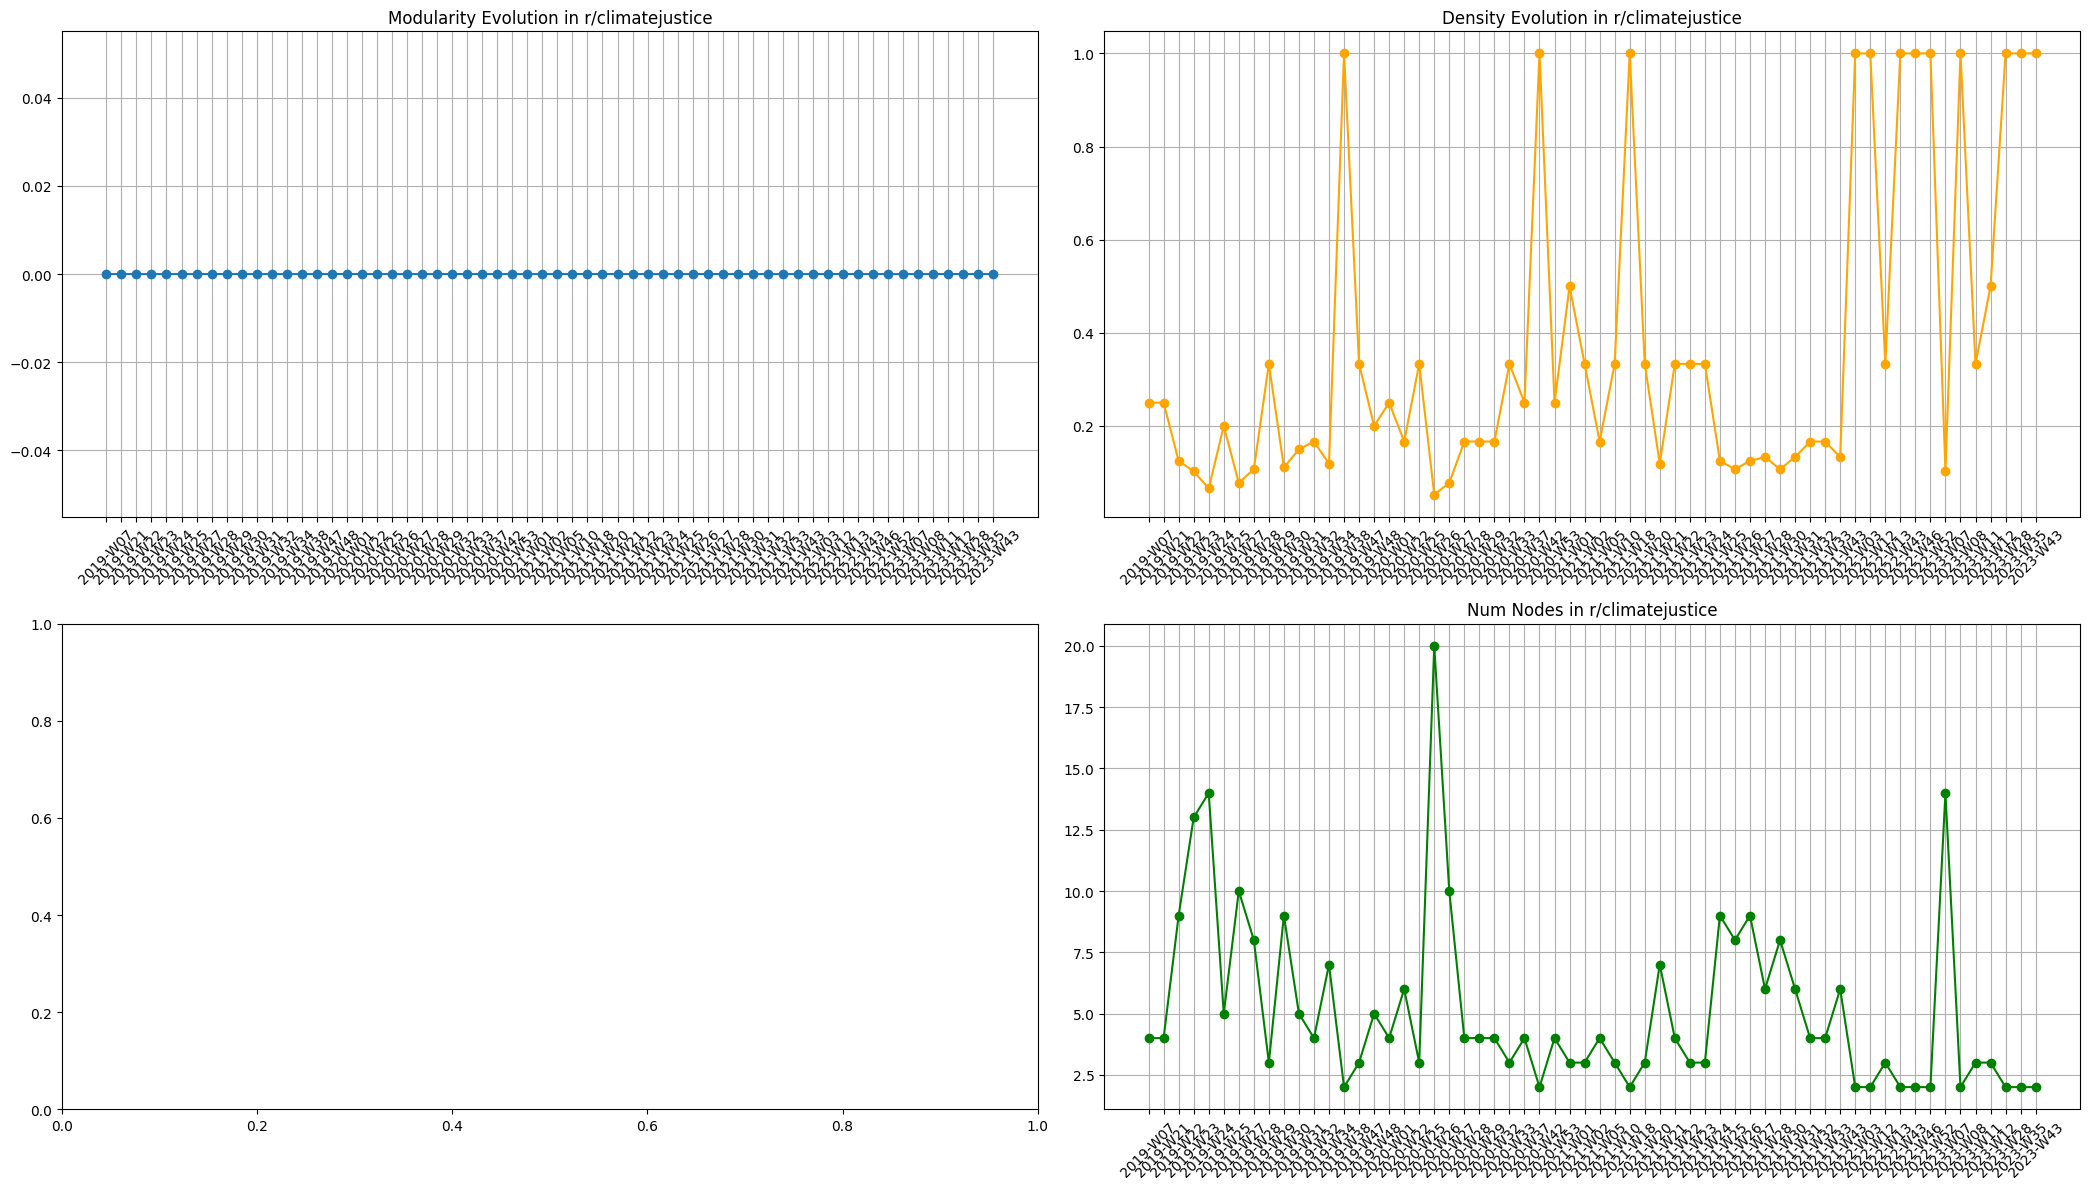

In [49]:
plot_subreddit_metrics(weekly_metrics,"climatejustice")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


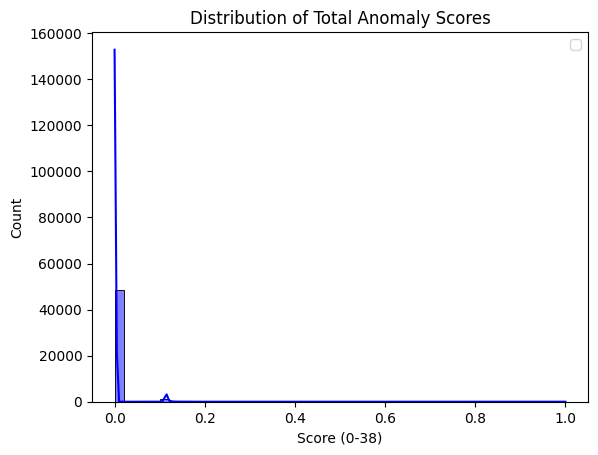

Anomaly Score Threshold (99th percentile): 1.41 / 38
Total anomalous users flagged: 500


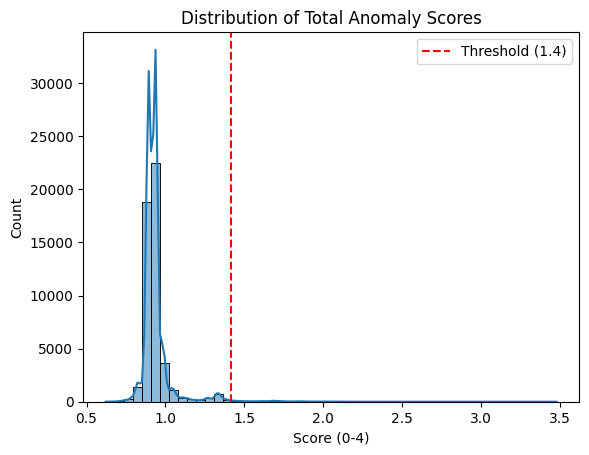

In [126]:
import numpy as np
node_metrics = final_analysis[1]
dynamic_metrics = weekly_metrics

def normalize_column(col):
    col_min = col.min()
    col_range = col.max() - col_min

    diff = 0.5 - (col.mean() / col_range)
    a = diff + (col - col_min) / col_range

    a = a.clip(0, 1)
    a = a*a*a

    return a

# 1. Spammer
node_metrics['Spammer_Ratio'] = node_metrics['Out_degree'] / (node_metrics['In_degree'] + 0.01)
node_metrics['Grade_Spammer'] = normalize_column(node_metrics['Spammer_Ratio'])

# 2. Artificial Bridger Grade
bc_pct = normalize_column(node_metrics['Betweenness_Score'])
pr_pct = normalize_column(node_metrics['PageRank_Score'])
node_metrics['Grade_Bridger'] = ((bc_pct + (1 - pr_pct)) / 2)

# 3. Peripheral Yeller
deg_pct = normalize_column(node_metrics['Degree'])
core_pct = normalize_column(node_metrics['Coreness_Level'])
node_metrics['Grade_Peripheral'] = ((deg_pct + (1 - core_pct)) / 2)

# 4. Sudden Leader Grade
leader_counts = dynamic_metrics[dynamic_metrics['Leader_Changed'] == 1]['Top_Leader'].value_counts()
node_metrics['Leader_Events'] = node_metrics['User'].map(leader_counts).fillna(0)
node_metrics['Grade_Leader'] = (node_metrics['Leader_Events'] * 5).clip(upper=10)/10

# 1. Burstiness (Volatility) 
all_comments = pd.read_csv('all_comments.csv')
# Extract Year-Week to group by
all_comments['Date & Time'] = pd.to_datetime(all_comments['Date & Time'])
all_comments['ISOYearWeek'] = all_comments['Date & Time'].dt.strftime('%G-W%V')
# Count how many comments a user made in each week they were active
user_weekly = all_comments.groupby(['Author', 'ISOYearWeek']).size().reset_index(name='Weekly_Count')
# Calculate Max and Mean weekly activity for each user
user_burstiness = user_weekly.groupby('Author')['Weekly_Count'].agg(['max', 'mean']).reset_index()
# Calculate Burst Ratio (adding 0.1 to avoid division by zero)
# High ratio means they post heavily in massive bursts and stop
user_burstiness['Burst_Ratio'] = user_burstiness['max'] / (user_burstiness['mean'] + 0.1)
# Map ratio to a 0-10 grade based on percentiles
user_burstiness['Grade_Burstiness'] = normalize_column(user_burstiness['Burst_Ratio'])
user_burstiness = user_burstiness.rename(columns={'Author': 'User'})

node_metrics = node_metrics.merge(user_burstiness[['User', 'Grade_Burstiness']], on='User', how='left').fillna({'Grade_Burstiness': 0})


# We consider a week "unstable" if the absolute structural changes are in the extreme 5%
dynamic_metrics['Abs_Delta_Density'] = dynamic_metrics['Delta_Density'].abs()
dynamic_metrics['Abs_Delta_Modularity'] = dynamic_metrics['Delta_Modularity'].abs()
density_thresh = dynamic_metrics['Abs_Delta_Density'].quantile(0.95)
mod_thresh = dynamic_metrics['Abs_Delta_Modularity'].quantile(0.95)
# Isolate the highly unstable events
unstable_weeks = dynamic_metrics[
    (dynamic_metrics['Abs_Delta_Density'] >= density_thresh) | 
    (dynamic_metrics['Abs_Delta_Modularity'] >= mod_thresh)
]
# Flag the users who were Top_Leader during these unstable weeks
unstable_leaders = unstable_weeks['Top_Leader'].value_counts().reset_index()
unstable_leaders.columns = ['User', 'Unstable_Leader_Events']
# Grade from 0-10 (e.g., 5 points per instability event, capped at 10)
unstable_leaders['Grade_Instability'] = normalize_column(unstable_leaders['Unstable_Leader_Events'] )
node_metrics = node_metrics.merge(unstable_leaders[['User', 'Grade_Instability']], on='User', how='left').fillna({'Grade_Instability': 0})

# Total Score
node_metrics['Total_Anomaly_Score'] = (1.1*node_metrics['Grade_Spammer'] + 
                                       node_metrics['Grade_Bridger'] + 
                                       0.4*node_metrics['Grade_Peripheral']+
                                       0.7*node_metrics['Grade_Leader']+
                                       1.2*node_metrics['Grade_Burstiness']+
                                       0.8*node_metrics['Grade_Instability'])

plt.figure()
#sns.histplot(node_metrics['Grade_Spammer'], color='red',bins=50, kde=True)
#sns.histplot(node_metrics['Grade_Bridger'], color='yellow', bins=50, kde=True)
#sns.histplot(node_metrics['Grade_Peripheral'], color='green', bins=50, kde=True)
sns.histplot(node_metrics['Grade_Instability'], color='blue', bins=50, kde=True)
#sns.histplot(user_burstiness['Grade_Burstiness'], color='black', bins=50, kde=True)


plt.title('Distribution of Total Anomaly Scores')
plt.xlabel('Score (0-38)')
plt.legend()
plt.show()
# Define Threshold (e.g., Top 1%)
threshold = node_metrics['Total_Anomaly_Score'].quantile(0.99)
#threshold = 2.3

print(f"Anomaly Score Threshold (99th percentile): {threshold:.2f} / 38")

# Flag anomalies
anomalous_df = node_metrics[node_metrics['Total_Anomaly_Score'] >= threshold]
anomalous_users = anomalous_df['User'].dropna().unique().tolist()

print(f"Total anomalous users flagged: {len(anomalous_users)}")

# Plot score distribution
plt.figure()
sns.histplot(node_metrics['Total_Anomaly_Score'], bins=50, kde=True)
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.1f})')
plt.title('Distribution of Total Anomaly Scores')
plt.xlabel('Score (0-4)')
plt.legend()
plt.show()


In [127]:
# Load all comments (this might take a moment if the file is large)
print("Loading all comments...")
all_comments = pd.read_csv('all_comments.csv')

# Filter for anomalous users
anomalous_comments = all_comments[all_comments['Author'].isin(anomalous_users)].copy()
print(f"Extracted {len(anomalous_comments)} comments generated by the anomalous users.")

# Drop missing content
anomalous_comments.dropna(subset=['Content'], inplace=True)

Loading all comments...
Extracted 52748 comments generated by the anomalous users.


In [128]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
# Initialize VADER
sia = SentimentIntensityAnalyzer()

def get_compound_sentiment(text):
    try:
        return sia.polarity_scores(str(text))['compound']
    except:
        return 0.0

print("Calculating sentiment polarity for anomalous users' comments...")
anomalous_comments['Sentiment_Compound'] = anomalous_comments['Content'].apply(get_compound_sentiment)

# Let's also do a random sample of normal users for comparison
normal_users = set(all_comments['Author'].unique()) - set(anomalous_users)
sample_normal_users = list(normal_users)[:min(1000,2*len(anomalous_users), 2*len(normal_users))]
normal_comments = all_comments[all_comments['Author'].isin(sample_normal_users)].copy()
normal_comments.dropna(subset=['Content'], inplace=True)

print("Calculating sentiment polarity for a random sample of normal users...")
normal_comments['Sentiment_Compound'] = normal_comments['Content'].apply(get_compound_sentiment)

Calculating sentiment polarity for anomalous users' comments...
Calculating sentiment polarity for a random sample of normal users...


In [129]:
print(len(normal_users))
print(len(anomalous_users))

52149
500


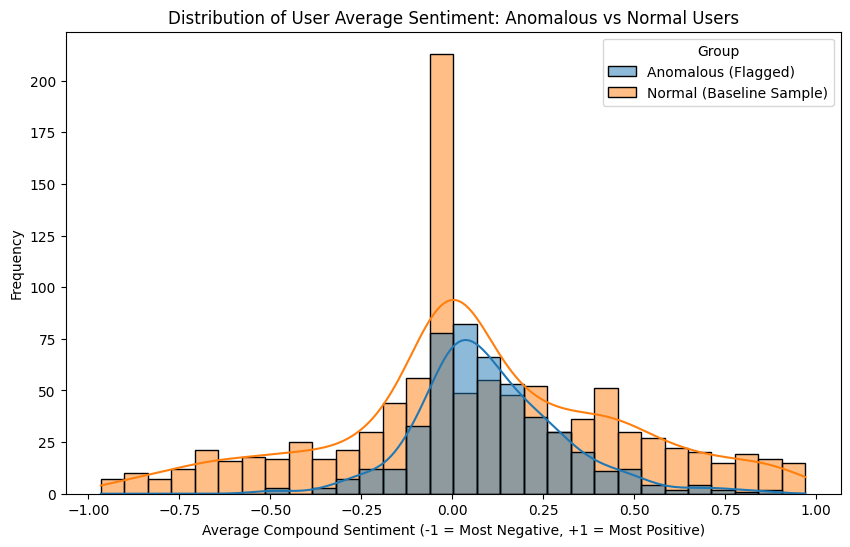

Top 10 Most Negative Anomalous Users:


,Author,Sentiment_Compound,Group
95,EmeraldFox88,-0.499667,Anomalous (Flagged)
141,Katatad,-0.493900,Anomalous (Flagged)
452,troglozyte,-0.477900,Anomalous (Flagged)
445,theora55,-0.355533,Anomalous (Flagged)
232,StopFossilFuels,-0.340567,Anomalous (Flagged)
374,kjleebio,-0.335822,Anomalous (Flagged)
398,optionhome,-0.314233,Anomalous (Flagged)
284,altaccountfiveyaboi,-0.289767,Anomalous (Flagged)
161,LyraSerpentine,-0.283893,Anomalous (Flagged)
305,caseyoli,-0.276543,Anomalous (Flagged)


In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate by user
anomalous_user_sentiment = anomalous_comments.groupby('Author')['Sentiment_Compound'].mean().reset_index()
anomalous_user_sentiment['Group'] = 'Anomalous (Flagged)'

normal_user_sentiment = normal_comments.groupby('Author')['Sentiment_Compound'].mean().reset_index()
normal_user_sentiment['Group'] = 'Normal (Baseline Sample)'

comparison_df = pd.concat([anomalous_user_sentiment, normal_user_sentiment])

# Plot the distribution of average sentiment scores
plt.figure(figsize=(10, 6))
sns.histplot(data=comparison_df, x='Sentiment_Compound', hue='Group', kde=True, bins=30, common_norm=False)
plt.title("Distribution of User Average Sentiment: Anomalous vs Normal Users")
plt.xlabel("Average Compound Sentiment (-1 = Most Negative, +1 = Most Positive)")
plt.ylabel("Frequency")
plt.show()

# Print Top 10 most negative anomalous users
negative_anomalous = anomalous_user_sentiment.sort_values(by='Sentiment_Compound').head(10)
print("Top 10 Most Negative Anomalous Users:")
display(negative_anomalous)

In [140]:
b = list(anomalous_user_sentiment.sort_values(by='Sentiment_Compound')['Author'].head(40))
b =  node_metrics.sort_values(by='Total_Anomaly_Score')['User'].head(40)

In [141]:
b

811         Infinite-Mud3931
3143            sethsnackman
2041          veterinarysite
1121       Quick-Parsnip3620
1882               WillyT_21
2438       Ornery-Honeydewer
2446             yoomtahzing
1927                Kagedeah
3181              legend0102
666                  shallah
1890                  lilvez
1773            AlmightyPoro
61          squishyghostling
1329               Jariiari7
7291           No-Safety-130
3174           FatefulFerret
4218               Dachedian
906              _Vespasian_
1245             Trump_Won4U
554               Salem1690s
458             AlexBehemoth
1867     Galacticemperor4000
1445            Far_East5003
314     Impressive-Slice-691
676            talk-to-peter
1736           JulianBefaros
998           AlGreenandBlue
1879            TheDinoKid21
3065             rad-thinker
349             TranceSetter
5541                  Wellsy
3969       researchexplainer
1884             Yorkshire80
8845            BrazenlyOzen
4474          

# Anomaly detection

In [135]:
alerts = detect_anomalies(final_analysis[0])
alert_community_manager(alerts)

KeyboardInterrupt: 

# Dynamic anylysis

# Verification

In [ ]:
core_list = final_analysis[final_analysis['Network_Role'] == 'Core (Backbone)']['User'].tolist()
anomaly_list = alerts['User'].tolist()

# Prove the core is the "Backbone"
frag_score = test_network_robustness(G, core_list)

# Prove that removing anomalies cleans the network
mod_before, mod_after = evaluate_filtering_impact(G, anomaly_list, community_mapping)

--- Robustness Testing (Structural Pillars) ---
Initial LCC Size: 49547
LCC Size after Core Removal: 15097
Network Fragmentation: 69.53% drop in connectivity.

--- Metric Evaluation (Noise Filtering) ---
Original Modularity: 0.6779
Filtered Modularity: 0.6796
Improvement: 0.25%
